# Dataset Description
## Intentional Homicide seggregate by gender

**Source**: Ministerio de Defensa Nacional.

**Download**: [download](https://www.datos.gov.co/Seguridad-y-Defensa/HOMICIDIO/m8fd-ahd9/about_data)

# Code
## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

## Load data

In [2]:
path = "./data/HOMICIDIO_20260816.csv"

incl_cols = [
    "FECHA HECHO",
    "SEXO",
    "CANTIDAD"
]

df = pd.read_csv(path, encoding="utf-8", usecols=incl_cols)

## Clean data

In [3]:
df["FECHA HECHO"] = pd.to_datetime(df["FECHA HECHO"], dayfirst=True)
df["FECHA HECHO"] = df["FECHA HECHO"].dt.year

by_sex = df.groupby(["FECHA HECHO", "SEXO"]).sum().reset_index()

female = by_sex[by_sex["SEXO"].str.lower().eq("femenino")]
male = by_sex[by_sex["SEXO"].str.lower().eq("masculino")] 
other = by_sex[
    ~(by_sex["SEXO"].str.lower().eq("masculino")) &
    ~(by_sex["SEXO"].str.lower().eq("femenino"))
]

def rename_col(df, name):
    df.rename(columns={f"FECHA HECHO": "Date", "CANTIDAD": name}, inplace=True)
    df.drop(columns=["SEXO"], inplace=True)
    
    return df

female = rename_col(female, "Female")
male = rename_col(male, "Male")
other = rename_col(other, "Other")

tmp = pd.merge(female, male, how="inner")
total = pd.merge(tmp, other, how="left")

total["Total"] = total[["Female", "Other"]].sum(axis=1)

## Plot

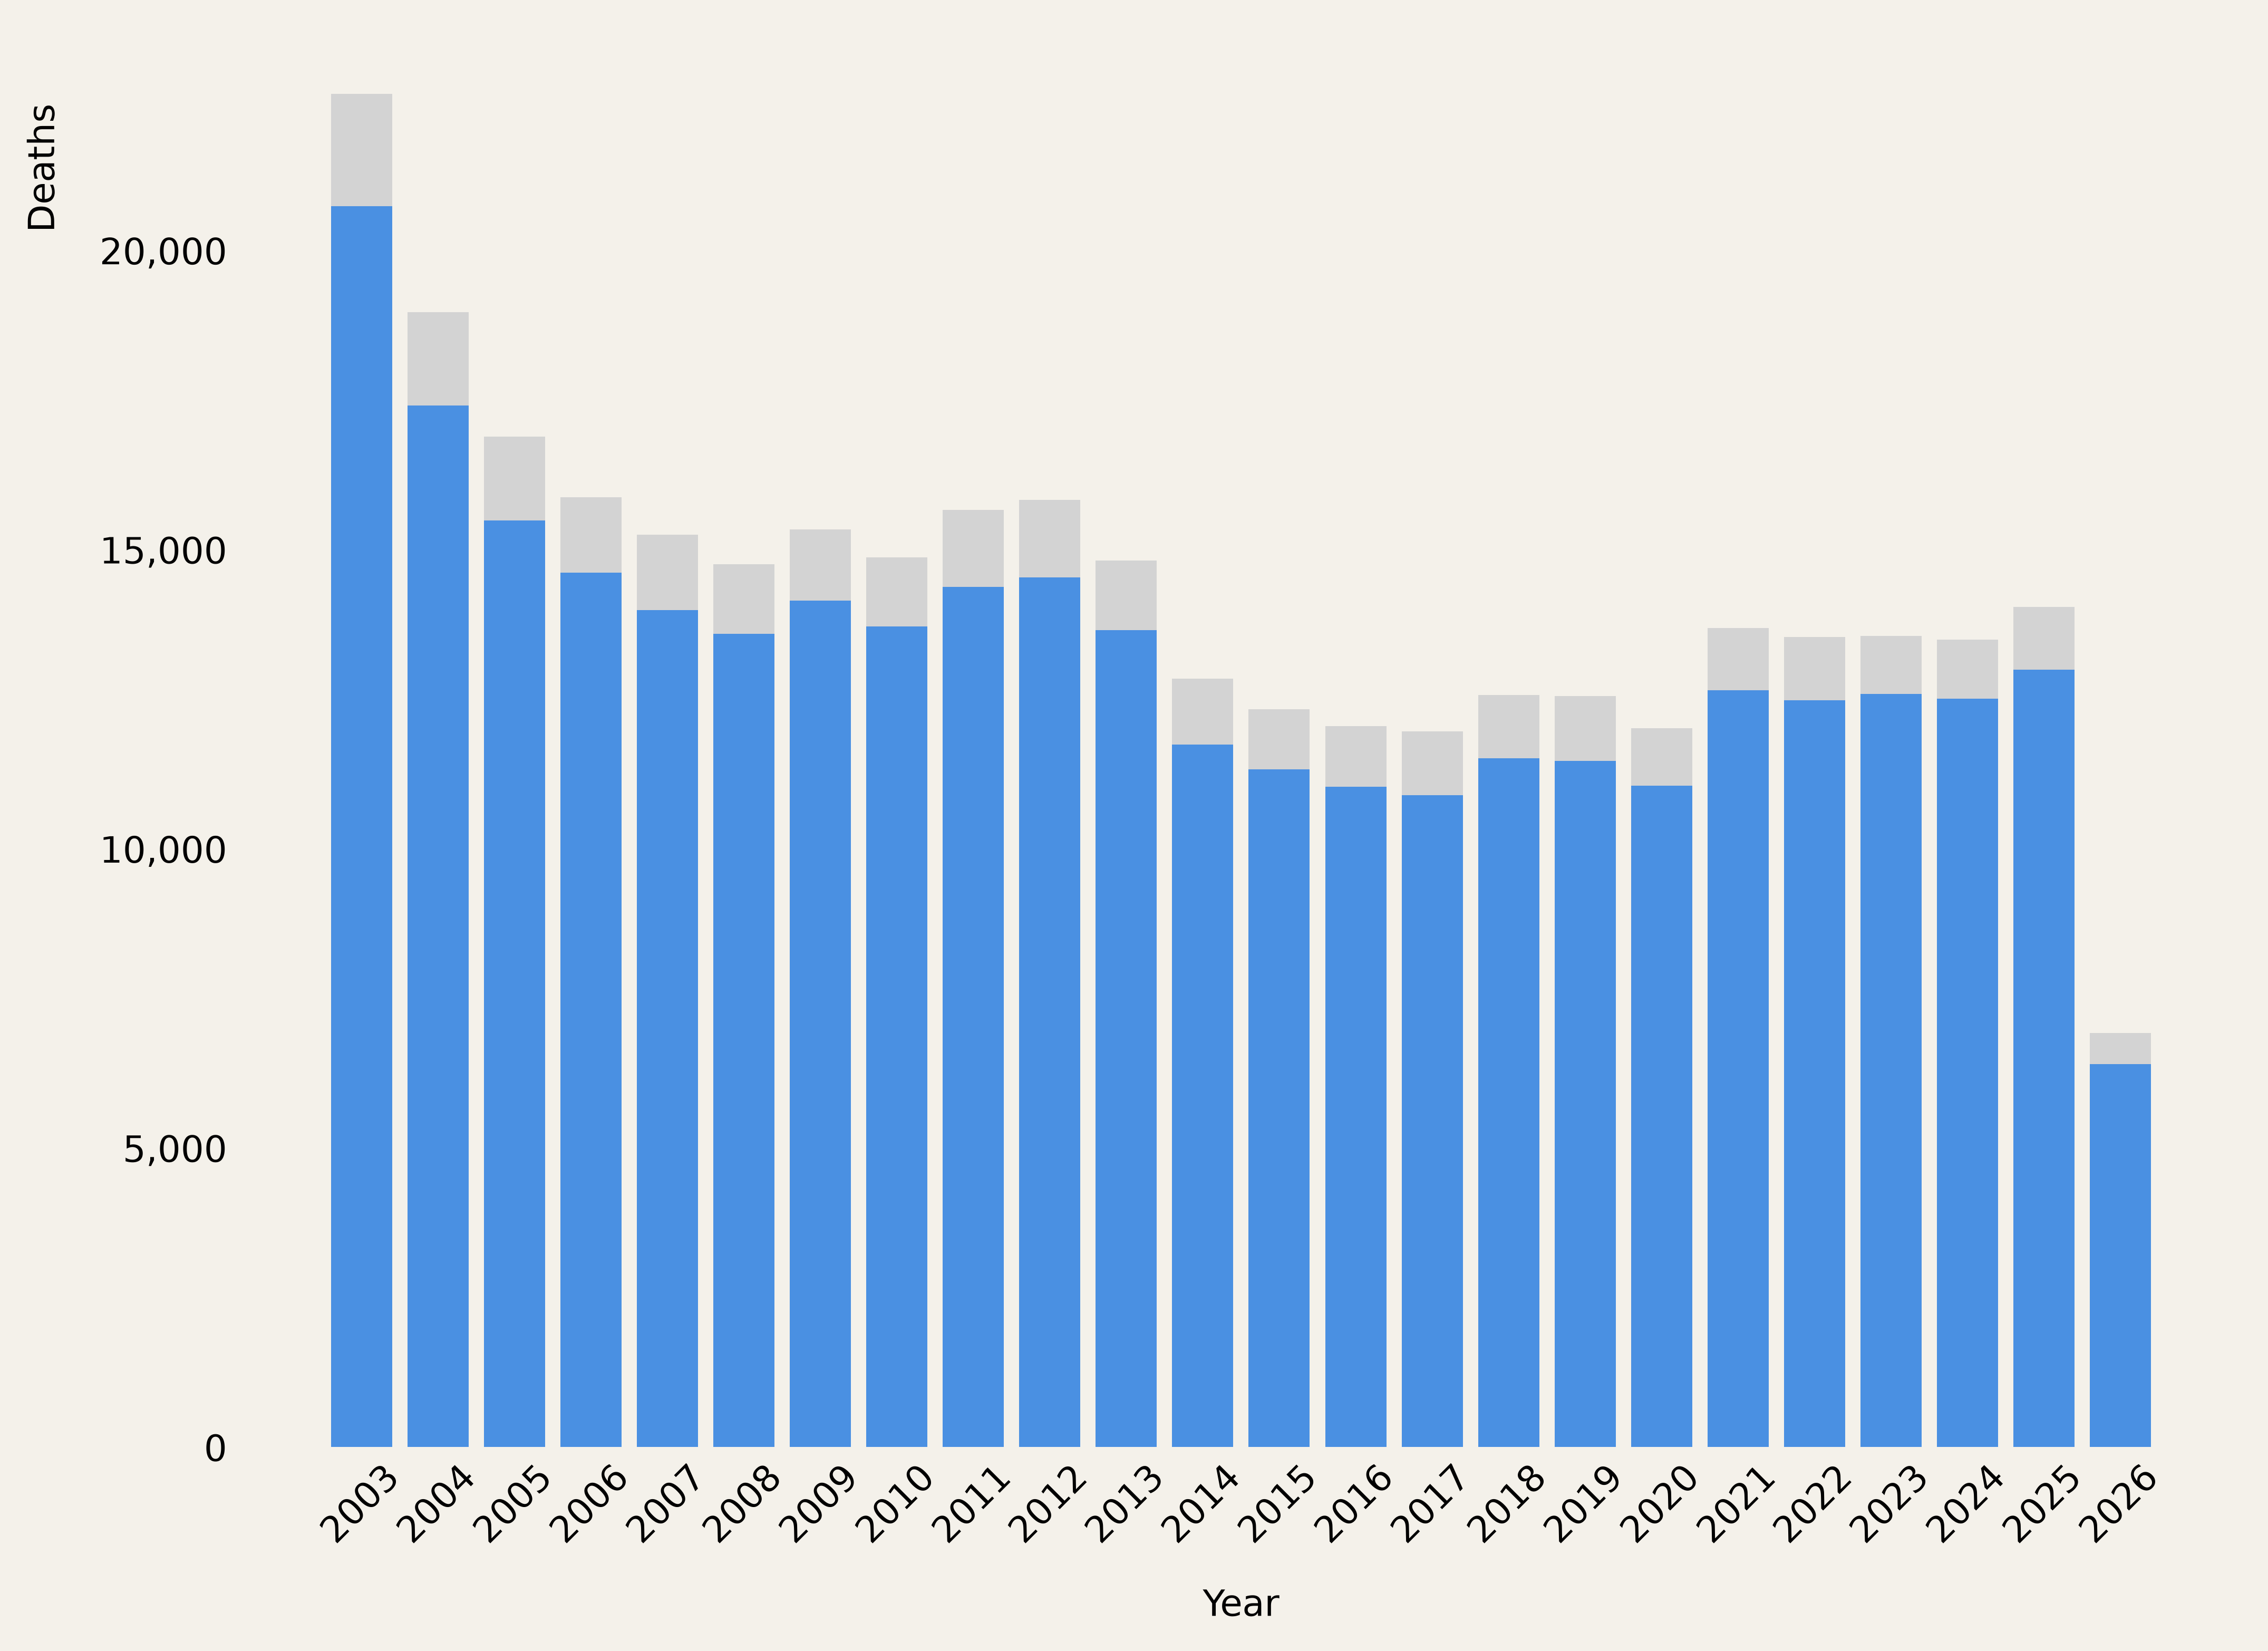

In [5]:
male_color = "#4a90e2"
background = "#F4F1EA"
gray = "#D3D3D3"
x_axis = total["Date"]

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

plt.bar(x_axis, total["Male"], color=male_color)
plt.bar(x_axis, total["Total"], bottom=total["Male"], color=gray)

plt.xticks(x_axis, rotation=45)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.ylabel("Deaths", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Year", labelpad=10, fontsize=10)

plt.show()